# Análisis de sentimientos

> Qué es una opinión (objetivo, aspecto, polaridad, autor y momento) y cómo medir su polaridad sin entrenar un modelo: léxicos de sentimiento (Bing Liu y VADER) evaluados frente a un clasificador supervisado en reseñas de Yelp, y análisis de sentimientos por aspectos con el árbol de dependencias de spaCy (qué se dice de la comida, del servicio o del precio). Con los errores típicos: confiar en un léxico general en un dominio concreto, ignorar la negación y el contraste, leer la puntuación de VADER en textos largos y reducir una reseña a una sola polaridad.
>
> **Requisitos previos:** [Clasificación de texto](06-clasificacion-de-texto.ipynb) · [Preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb) · **Relacionado:** [Sentimientos con deep learning](08-sentimientos-con-deep-learning.ipynb) · [Detección de temas](05-deteccion-de-temas.ipynb)

## 1. Idea clave

El **análisis de sentimientos** (*sentiment analysis* u *opinion mining*) extrae de un texto qué opina alguien y sobre qué. Se puede hacer a tres niveles: el **documento** («esta reseña es negativa»), la **oración** y el **aspecto** («la comida, bien; el servicio, mal»). El nivel de documento es un problema de [clasificación de texto](06-clasificacion-de-texto.ipynb); el de aspecto, el más útil para un negocio, necesita además encontrar de qué se habla y qué se dice de cada cosa.

Hay dos familias de métodos. Los **léxicos de sentimiento** son listas de palabras con su polaridad (*great* +, *rude* −) y reglas para combinarlas: no necesitan datos etiquetados, son transparentes y sirven como punto de partida, pero fallan con el vocabulario del dominio, la negación, la ironía y los textos largos. Los **modelos supervisados** (TF-IDF con regresión logística, [redes neuronales](08-sentimientos-con-deep-learning.ipynb), [BERT](10-modelos-de-lenguaje-preentrenados.ipynb)) aprenden todo eso de ejemplos etiquetados y son mucho más precisos cuando los hay.

## 2. Conceptos importantes

### 2.1. Los componentes de una opinión

Liu (2012) define una opinión como una quíntupla $(e, a, s, h, t)$:

- $e$, la **entidad** u objetivo (*target*): el restaurante, el producto. Aparece con distintos nombres (*Joe's Pizza*, *this place*, *it*): hay que resolver sinónimos y referencias (correferencia).
- $a$, el **aspecto** de la entidad sobre el que se opina: la comida, el servicio, el precio. Puede ser explícito (*the service was slow*) o implícito (*we waited an hour* habla del servicio sin nombrarlo).
- $s$, el **sentimiento** u orientación: positivo, negativo o neutro, o una puntuación con intensidad.
- $h$, el **autor** de la opinión (*opinion holder*): en una reseña, quien la escribe; en una noticia, puede ser una persona citada.
- $t$, el **momento**: las opiniones cambian (un restaurante que cambia de dueño).

Un texto puede contener muchas quíntuplas, con aspectos de polaridad opuesta: *great food, terrible service*.

### 2.2. Léxicos de sentimiento

- **Léxico de opinión de Bing Liu** (Hu y Liu, 2004): unas 2 000 palabras positivas y 4 800 negativas, sin intensidad, recopiladas de reseñas de productos. La puntuación más simple de un texto es (positivas − negativas) / número de palabras.
- **VADER** (Hutto y Gilbert, 2014): unas 7 500 entradas con intensidad entre −4 y +4, valoradas por personas y pensadas para redes sociales (incluye emoticonos y jerga), más **reglas**: la negación invierte la polaridad (*not good*), los intensificadores la aumentan (*very good*), las mayúsculas y las exclamaciones la refuerzan, y tras *but* pesa más lo que viene después. Devuelve las proporciones de texto positivo, negativo y neutro y una puntuación **compuesta** (*compound*) entre −1 y 1: la suma de las valencias normalizada con $x/\sqrt{x^2 + 15}$. Por convenio, *compound* ≥ 0,05 es positivo y ≤ −0,05, negativo.
- Otros: AFINN (palabras con valores de −5 a 5), SentiWordNet (polaridad para cada synset de [WordNet](05-deteccion-de-temas.ipynb)), NRC (emociones además de polaridad).

### 2.3. Análisis por aspectos

Se divide en tres pasos:

1. **Extraer los aspectos**: nombres o sintagmas nominales frecuentes (*food*, *service*, *wait time*), patrones gramaticales como en [n-gramas y colocaciones](02-n-gramas-y-colocaciones.ipynb), [temas](05-deteccion-de-temas.ipynb) o modelos entrenados.
2. **Asociar cada palabra de opinión a su aspecto**: el **árbol de dependencias** indica qué palabra modifica a cuál. Las dos relaciones más útiles en inglés son el modificador adjetival `amod` (*rude* → *waiter* en *a rude waiter*) y el complemento de un verbo copulativo `acomp` con su sujeto `nsubj` (*the service was slow*). Una negación `neg` sobre el adjetivo o el verbo invierte la polaridad.
3. **Agregar** por aspecto o por categoría de aspectos (comida, servicio, precio, ambiente).

## 3. Código

Usamos el mismo corpus que en el resto de la sección: las 50 000 reseñas de prueba de **Yelp Review Full** (Zhang, Zhao y LeCun, 2015), de negocios de todo tipo y con sus estrellas, descargadas de Hugging Face y guardadas en `data/`. Los léxicos de Bing Liu y VADER vienen con NLTK, y el árbol de dependencias lo da spaCy (`en_core_web_sm`).

In [1]:
import contextlib
import html
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import spacy
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from huggingface_hub.utils import logging as hf_logging
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="NLTK will not authorize")   # aviso de permisos del directorio de NLTK
for resource in ["vader_lexicon", "opinion_lexicon"]:
    nltk.download(resource, quiet=True)
from nltk.corpus import opinion_lexicon
from nltk.sentiment import SentimentIntensityAnalyzer

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    yelp = load_dataset(
        "Yelp/yelp_review_full",
        data_files={"test": "yelp_review_full/test-00000-of-00001.parquet"},   # solo el conjunto de prueba
        split="test",
        cache_dir="data",
        verification_mode="no_checks",                     # no exige descargar también el de entrenamiento
    )

def clean(text):
    text = text.replace("\\n", " ").replace('\\"', '"')    # secuencias escapadas
    text = html.unescape(text)                              # &amp; -> &
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URL
    return re.sub(r"\s+", " ", text).strip()

reviews = yelp.to_pandas()
reviews["stars"] = reviews["label"] + 1
reviews["clean"] = reviews["text"].map(clean)
print(reviews.shape)

(50000, 4)


### 3.1. Los léxicos y las reglas de VADER

Primero, el tamaño de cada léxico y cómo trata VADER frases con negación, intensificadores, mayúsculas, contraste e ironía.

In [3]:
vader = SentimentIntensityAnalyzer()
liu_pos, liu_neg = set(opinion_lexicon.positive()), set(opinion_lexicon.negative())
print(f"Bing Liu: {len(liu_pos):,} positivas y {len(liu_neg):,} negativas · VADER: {len(vader.lexicon):,} entradas")

sentences = ["The food was good.", "The food was very good.", "The food was GOOD!!!", "The food was not good.",
             "Not bad at all.", "The food was good, but the service was terrible.",
             "The pizza was bland.", "Great, another 45 minute wait. Just what I wanted."]
pd.DataFrame([{"frase": s, **vader.polarity_scores(s)} for s in sentences]).set_index("frase")

Bing Liu: 2,006 positivas y 4,783 negativas · VADER: 7,502 entradas


,neg,neu,pos,compound
frase,,,,
The food was good.,0.000,0.508,0.492,0.4404
The food was very good.,0.000,0.556,0.444,0.4927
The food was GOOD!!!,0.000,0.400,0.600,0.6714
The food was not good.,0.376,0.624,0.000,-0.3412
Not bad at all.,0.000,0.513,0.487,0.4310
"The food was good, but the service was terrible.",0.317,0.534,0.149,-0.4939
The pizza was bland.,0.000,1.000,0.000,0.0000
"Great, another 45 minute wait. Just what I wanted.",0.000,0.631,0.369,0.6249


- Las reglas funcionan en los casos de libro: *very* sube la puntuación (de 0,44 a 0,49), las mayúsculas y las exclamaciones aún más (0,67), *not good* pasa a negativa (−0,34) y en la frase con *but* pesa más lo que viene después (−0,49).
- Pero *bland*, la queja más típica sobre la comida, no está en el léxico (0,00); *not bad at all* se queda en un positivo tibio (0,43, menos que *good*), y la ironía (*great, another 45 minute wait*) sale claramente positiva (0,62).

### 3.2. ¿Cuánto aciertan los léxicos?

Puntuamos 10 000 reseñas con los dos léxicos: VADER con su *compound* y Bing Liu con (positivas − negativas) / palabras. Vemos primero cómo se distribuyen las puntuaciones según las estrellas.

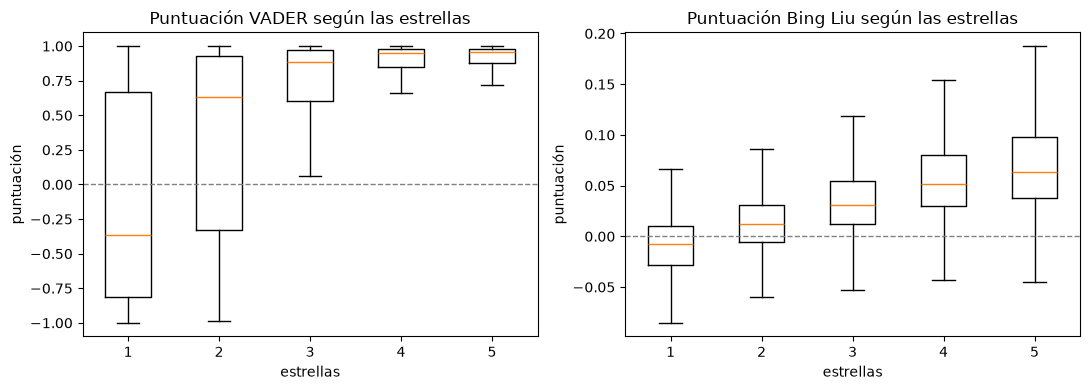

stars,1,2,3,4,5
VADER,-0.362,0.634,0.886,0.947,0.954
Bing Liu,-0.007,0.012,0.031,0.052,0.064


In [4]:
sample = reviews.sample(10_000, random_state=42).copy()

def tokens(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

def liu_score(text):
    words = tokens(text)
    return (sum(w in liu_pos for w in words) - sum(w in liu_neg for w in words)) / max(1, len(words))

sample["VADER"] = [vader.polarity_scores(t)["compound"] for t in sample["clean"]]
sample["Bing Liu"] = sample["clean"].map(liu_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["VADER", "Bing Liu"]):
    ax.boxplot([sample.loc[sample["stars"] == s, col] for s in range(1, 6)], showfliers=False)
    ax.set_xticks(range(1, 6), range(1, 6))
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set(title=f"Puntuación {col} según las estrellas", xlabel="estrellas", ylabel="puntuación")
plt.tight_layout()
plt.show()
sample.groupby("stars")[["VADER", "Bing Liu"]].median().round(3).T

- Las dos puntuaciones suben con las estrellas, pero VADER tiene un **sesgo positivo** fuerte: la mediana de las reseñas de 2 estrellas es +0,63, y la de las de 3, +0,89. Solo las de 1 estrella tienen la mediana negativa: con el umbral de 0,05, la mayoría de las reseñas de 2 estrellas serían positivas.
- Bing Liu también se desplaza hacia arriba (las reseñas usan palabras positivas incluso para quejarse: *the food was good, but…*), pero las medianas de 1 y 2 estrellas quedan cerca de cero (−0,007 y 0,012) y las cajas están más separadas.

Ahora los comparamos como clasificadores de reseñas negativas (1–2 estrellas) frente a positivas (4–5), con su umbral habitual (0,05 para VADER, 0 para Bing Liu), y frente a una regresión logística con TF-IDF entrenada con las otras 40 000 reseñas (la de [clasificación de texto](06-clasificacion-de-texto.ipynb)). Las 10 000 reseñas de la muestra no se usan para entrenar.

In [5]:
binary = sample[sample["stars"] != 3]
y_true = (binary["stars"] >= 4).astype(int)

train = reviews.drop(sample.index)
train = train[train["stars"] != 3]
supervised = make_pipeline(TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True),
                           LogisticRegression(max_iter=1_000))
supervised.fit(train["clean"], (train["stars"] >= 4).astype(int))

methods = {
    "VADER (compound ≥ 0,05)": (binary["VADER"] >= 0.05, binary["VADER"]),
    "Bing Liu (puntuación > 0)": (binary["Bing Liu"] > 0, binary["Bing Liu"]),
    "regresión logística (TF-IDF)": (supervised.predict(binary["clean"]), supervised.predict_proba(binary["clean"])[:, 1]),
}
pd.DataFrame({name: {"exactitud": accuracy_score(y_true, pred), "F1 macro": f1_score(y_true, pred, average="macro"),
                     "ROC AUC": roc_auc_score(y_true, score)}
              for name, (pred, score) in methods.items()}).T.round(3)

,exactitud,F1 macro,ROC AUC
"VADER (compound ≥ 0,05)",0.714,0.696,0.827
Bing Liu (puntuación > 0),0.732,0.722,0.874
regresión logística (TF-IDF),0.930,0.930,0.980


Los dos léxicos aciertan en torno al 71–73 % (F1 macro 0,70 y 0,72), y el recuento simple de Bing Liu supera a VADER también en capacidad de ordenar (AUC 0,874 frente a 0,827). La regresión logística, entrenada con 40 000 reseñas del mismo dominio, llega al 93 %: cuando hay etiquetas, un modelo supervisado sencillo gana con mucha diferencia. Los léxicos tienen sentido cuando no hay etiquetas, o como variables adicionales.

### 3.3. El vocabulario del dominio

¿Qué palabras pesan más en el modelo supervisado y qué dicen de ellas los léxicos?

In [6]:
vocab = supervised.named_steps["tfidfvectorizer"].get_feature_names_out()
coefs = supervised.named_steps["logisticregression"].coef_[0]
unigrams = [(w, c) for w, c in zip(vocab, coefs) if " " not in w]
top_negative = sorted(unigrams, key=lambda x: x[1])[:25]

def liu_label(w):
    return "+" if w in liu_pos else "−" if w in liu_neg else ""

table = pd.DataFrame([{"palabra": w, "coeficiente": round(c, 1), "VADER": vader.lexicon.get(w, ""), "Bing Liu": liu_label(w)}
                      for w, c in top_negative]).set_index("palabra")
print(f"De las 25 palabras más negativas para el modelo: {(table['VADER'] == '').sum()} no están en VADER y "
      f"{(table['Bing Liu'] == '').sum()} no están en Bing Liu")
table

De las 25 palabras más negativas para el modelo: 12 no están en VADER y 11 no están en Bing Liu


,coeficiente,VADER,Bing Liu
palabra,,,
not,-10.4,,
worst,-6.4,-3.1,−
no,-6.3,-1.2,
horrible,-6.0,-2.5,−
terrible,-5.7,-2.1,−
bland,-5.4,,−
ok,-5.4,1.2,
rude,-5.4,-2.0,−
bad,-4.7,-2.5,−


Casi la mitad de las 25 palabras con más peso hacia «negativa» no están en los léxicos. Faltan las negaciones *not*, *no* y *nothing* en Bing Liu (VADER las trata con reglas), palabras del dominio como *money* (quejas por el precio) o *should* (*they should have…*), y adjetivos clave: *bland*, *mediocre*, *overpriced* y *slow* no están en VADER, y *dry* no está en ninguno. Y hay signos cambiados: VADER valora *ok* y *okay* como positivas (+1,2 y +0,9), cuando en una reseña «*the food was ok*» es una crítica, y los dos léxicos marcan *better* como positiva, pero el modelo le da un peso negativo (−4,3): en las reseñas aparece a menudo en quejas (*I've had better*, *could have been better*).

### 3.4. Sentimientos por aspectos

Analizamos 5 000 reseñas con el modelo completo de spaCy (etiquetador y analizador de dependencias). Para cada adjetivo buscamos el nombre al que se refiere:

- `amod`: el adjetivo modifica directamente al nombre (*a **rude** waiter*).
- `acomp`: el adjetivo es el complemento de un verbo copulativo cuyo sujeto (`nsubj`) es un nombre (*the service was **slow***).

Si el adjetivo o el verbo tienen una negación (`neg`), invertimos la polaridad. La polaridad de cada adjetivo es su valor en VADER o, si no está, ±1 según Bing Liu.

In [7]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

doc = nlp("The waiter was not friendly, but the pizza was amazing and the prices were reasonable for a busy place.")
for t in doc:
    if t.pos_ in ("ADJ", "NOUN", "AUX", "PART"):
        print(f"{t.text:<11} {t.pos_:<5} {t.dep_:<7} -> {t.head.text}")

waiter      NOUN  nsubj   -> was
was         AUX   ROOT    -> was
not         PART  neg     -> was
friendly    ADJ   acomp   -> was
pizza       NOUN  nsubj   -> was
was         AUX   conj    -> was
amazing     ADJ   acomp   -> was
prices      NOUN  nsubj   -> were
were        AUX   conj    -> was
reasonable  ADJ   acomp   -> were
busy        ADJ   amod    -> place
place       NOUN  pobj    -> for


In [8]:
def opinion_polarity(adj):
    if adj in vader.lexicon:
        return vader.lexicon[adj]
    return 1.0 if adj in liu_pos else -1.0 if adj in liu_neg else 0.0

def aspect_opinions(doc):
    pairs = []
    for t in doc:
        if t.pos_ != "ADJ":
            continue
        if t.dep_ == "amod" and t.head.pos_ == "NOUN":
            nouns, negated = [t.head], any(c.dep_ == "neg" for c in t.children)
        elif t.dep_ == "acomp":                            # «the service was slow»: el sujeto cuelga del verbo
            nouns = [c for c in t.head.children if c.dep_ == "nsubj" and c.pos_ == "NOUN"]
            negated = any(c.dep_ == "neg" for c in list(t.children) + list(t.head.children))
        else:
            continue
        for noun in nouns:
            polarity = opinion_polarity(t.lemma_.lower())
            pairs.append((noun.lemma_.lower(), ("not " if negated else "") + t.lemma_.lower(),
                          -polarity if negated else polarity))
    return pairs

print(aspect_opinions(doc))

[('waiter', 'not friendly', -2.2), ('pizza', 'amazing', 2.8), ('price', 'reasonable', 1.0), ('place', 'busy', 0.0)]


In [9]:
aspect_sample = reviews.sample(5_000, random_state=7)
rows = []
for doc, stars in zip(nlp.pipe(aspect_sample["clean"], batch_size=200, n_process=4), aspect_sample["stars"]):
    rows += [(aspect, opinion, pol, stars) for aspect, opinion, pol in aspect_opinions(doc)]
opinions = pd.DataFrame(rows, columns=["aspecto", "opinión", "polaridad", "estrellas"])
print(f"Pares aspecto-opinión: {len(opinions):,} · con polaridad conocida: {(opinions['polaridad'] != 0).mean():.0%}")
opinions["aspecto"].value_counts().head(15).to_dict()

Pares aspecto-opinión: 36,167 · con polaridad conocida: 49%


{'food': 1541,
 'place': 1256,
 'time': 1137,
 'service': 1089,
 'thing': 586,
 'experience': 495,
 'restaurant': 484,
 'price': 435,
 'staff': 385,
 'room': 303,
 'drink': 289,
 'sauce': 263,
 'selection': 262,
 'people': 253,
 'night': 245}

Salen unos 36 000 pares, pero solo la mitad (49 %) tienen un adjetivo con polaridad en los léxicos: el resto son descriptivos (*busy*, *big*, *first*). Los aspectos más frecuentes son los esperados (*food*, *service*, *price*, *staff*), junto con nombres genéricos (*place*, *time*, *thing*, *experience*) que hay que agrupar o descartar. Para resumir, agrupamos los aspectos en cuatro categorías a mano, como en las tareas de análisis por aspectos de reseñas de restaurantes (comida, servicio, precio, ambiente).

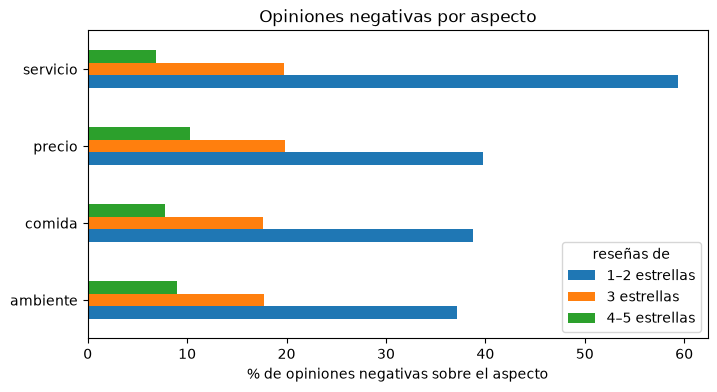

grupo,1–2 estrellas,3 estrellas,4–5 estrellas
categoría,,,
ambiente,159,141,245
comida,877,597,1129
precio,93,106,242
servicio,660,359,681


In [10]:
categories = {
    "comida": {"food", "dish", "meal", "sauce", "pizza", "burger", "chicken", "flavor", "taste", "portion", "fry",
               "steak", "salad", "sushi", "dessert", "menu", "selection"},
    "servicio": {"service", "staff", "server", "waiter", "waitress", "manager", "employee", "owner", "bartender"},
    "precio": {"price", "value", "bill", "cost", "deal"},
    "ambiente": {"atmosphere", "decor", "music", "ambiance", "ambience", "vibe", "room", "patio"},
}
to_category = {w: c for c, words in categories.items() for w in words}
opinions["categoría"] = opinions["aspecto"].map(to_category)
known = opinions[opinions["categoría"].notna() & (opinions["polaridad"] != 0)].copy()
known["grupo"] = np.where(known["estrellas"] <= 2, "1–2 estrellas", np.where(known["estrellas"] >= 4, "4–5 estrellas", "3 estrellas"))
known["negativa"] = known["polaridad"] < 0

summary = known.pivot_table(index="categoría", columns="grupo", values="negativa", aggfunc="mean")
counts = known.pivot_table(index="categoría", columns="grupo", values="negativa", aggfunc="size")
ax = (100 * summary[["1–2 estrellas", "3 estrellas", "4–5 estrellas"]]).plot.barh(figsize=(8, 4))
ax.set(title="Opiniones negativas por aspecto", xlabel="% de opiniones negativas sobre el aspecto", ylabel="")
ax.legend(title="reseñas de")
plt.show()
counts

- En las reseñas de 1–2 estrellas, el **servicio** es el aspecto peor tratado: el 59 % de las opiniones sobre él son negativas, frente al 37–40 % de la comida, el precio y el ambiente. Las malas experiencias se cuentan sobre todo por el trato.
- En las de 4–5 estrellas, ningún aspecto pasa del 11 % de opiniones negativas, y las de 3 estrellas quedan en medio (entre el 17 % y el 20 %).
- Incluso en las peores reseñas, entre el 40 % y el 60 % de las opiniones sobre cada aspecto son positivas: una reseña de 1 estrella puede elogiar la comida y hundir el servicio. Eso es lo que se pierde con una sola polaridad por reseña (sección 4).
- Los recuentos (tabla) son pequeños para el precio y el ambiente en las reseñas negativas (93 y 159 opiniones), así que esas barras tienen más incertidumbre.

In [11]:
negative_reviews = known[known["estrellas"] <= 2]
for category in categories:
    top = negative_reviews.loc[(negative_reviews["categoría"] == category) & negative_reviews["negativa"], "opinión"]
    print(f"{category:<9} {', '.join(f'{o} ({n})' for o, n in top.value_counts().head(6).items())}")

comida    bad (39), bland (30), mediocre (29), not good (25), terrible (20), cold (12)
servicio  bad (62), slow (45), poor (38), horrible (37), rude (34), terrible (31)
precio    low (6), ridiculous (5), exorbitant (4), expensive (3), outrageous (3), cheap (3)
ambiente  loud (11), empty (3), cheap (3), bad (3), horrible (3), dirty (3)


Las palabras concretan las quejas: comida *bland*, *mediocre* o *cold*; servicio *slow*, *poor* o *rude*. Y aparece un error del léxico: en el precio, la opinión negativa más frecuente es *low*, que Bing Liu marca como negativa, pero *low prices* es un elogio. Como con *cold* (sección 4), la polaridad de un adjetivo depende del aspecto al que acompaña.

## 4. Parámetros importantes y errores comunes

| Decisión | Qué controla | Consejo |
|---|---|---|
| Léxico | Vocabulario y escala de polaridad | VADER para textos cortos e informales; Bing Liu para reseñas; amplíalo con las palabras del dominio |
| Umbral de VADER (`compound`) | Frontera positivo / neutro / negativo | ±0,05 por convenio; con textos largos, ajústalo con datos etiquetados o usa la proporción `neg`/`pos` |
| Nivel de análisis | Documento, oración o aspecto | Por oración o por aspecto en textos largos con opiniones mezcladas |
| Relaciones de dependencia (`amod`, `acomp`, `neg`) | Qué pares aspecto-opinión se extraen | Revisa una muestra: el analizador falla en frases largas y coordinadas |
| Lista de aspectos y categorías | Qué se agrega | Parte de los nombres más frecuentes en los pares; agrúpalos a mano o con [embeddings](04-embeddings-de-palabras.ipynb) |
| Modelo de spaCy | Precisión del árbol de dependencias | `sm` basta para explorar; `trf` es más preciso y mucho más lento |

**Errores comunes y lecciones aprendidas**

- **Confiar en un léxico general en un dominio concreto.** VADER está pensado para redes sociales, y en reseñas le faltan muchas de las palabras clave del dominio (*bland*, *overpriced*, *slow*; sección 3.3). Y la polaridad depende del dominio y del aspecto: en Bing Liu, *cold* es negativa, pero *the beer was cold* es un elogio (demo abajo), y *low* es negativa, así que *low prices* acaba siendo la queja más frecuente sobre el precio (sección 3.4). Antes de usar un léxico, mira qué palabras importantes del corpus no tiene o tiene con el signo cambiado, y amplíalo.
- **Leer la puntuación de VADER en textos largos.** La puntuación compuesta suma las valencias de todas las palabras y las normaliza, así que en una reseña larga con muchas palabras positivas y negativas acaba casi siempre cerca de ±1: VADER no promedia, acumula (demo abajo). Las reseñas de 2 estrellas tienen una mediana positiva (sección 3.2). Puntúa por oraciones y agrega, o usa un modelo supervisado.
- **Ignorar la negación, el contraste y la ironía.** Un recuento de palabras como el de Bing Liu no ve el *not* de *not good*; VADER sí, pero *not bad at all* le sigue pareciendo poco positivo y la ironía (*great, another 45 minute wait*) le parece muy positiva (sección 3.1).
- **Reducir una reseña a una sola polaridad.** En un análisis propio de reseñas de restaurantes de Yelp, los aspectos peor valorados se dedujeron de las palabras con más peso hacia la clase negativa de un clasificador: *bland* y *dry* (calidad de la comida), *rude* (servicio), *disappointed* (expectativas). Sirve como primera aproximación, pero no dice de qué se queja cada reseña ni si la misma reseña elogia otra cosa. El análisis por aspectos (sección 3.4) asigna cada opinión a su aspecto y permite contar, por ejemplo, cuántas reseñas negativas critican el servicio aunque elogien la comida.
- **Tomar los pares extraídos sin revisarlos.** Las reglas de dependencias fallan con frases largas, coordinadas o mal puntuadas, y la negación puede quedar lejos del adjetivo (*I don't think the food was good*). Revisa una muestra de los pares antes de sacar conclusiones.

In [12]:
# 1) La polaridad depende del dominio
for text in ["The beer was cold.", "The soup was cold.", "The portions were small.", "The line was long."]:
    words = tokens(text)
    print(f"{text:<26} VADER {vader.polarity_scores(text)['compound']:+.2f} · "
          f"Bing Liu: {[w for w in words if w in liu_pos or w in liu_neg]} -> {liu_score(text):+.2f}")

# 2) VADER acumula: en textos largos, |compound| se acerca a 1
length = sample["clean"].str.split().str.len()
quartiles = pd.qcut(length, 4)
saturated = (sample["VADER"].abs() > 0.9).groupby(quartiles, observed=True).mean()
print("\n% de reseñas con |compound| > 0,9 según su longitud (palabras):")
print((100 * saturated).round(0).to_string())

The beer was cold.         VADER +0.00 · Bing Liu: ['cold'] -> -0.25
The soup was cold.         VADER +0.00 · Bing Liu: ['cold'] -> -0.25
The portions were small.   VADER +0.00 · Bing Liu: [] -> +0.00
The line was long.         VADER +0.00 · Bing Liu: [] -> +0.00



% de reseñas con |compound| > 0,9 según su longitud (palabras):
clean
(0.999, 53.0]     24.0
(53.0, 102.0]     42.0
(102.0, 180.0]    58.0
(180.0, 962.0]    74.0


## 5. Comparación con métodos relacionados

| Método | Necesita | Ventajas | Inconvenientes | Cuándo usarlo |
|---|---|---|---|---|
| Léxico + reglas (VADER, Bing Liu) | Nada (solo el léxico) | Inmediato, transparente, sin datos etiquetados | Vocabulario general; falla con negación compleja, ironía, textos largos | Exploración rápida, textos cortos, sin etiquetas |
| [Clasificación supervisada](06-clasificacion-de-texto.ipynb) (TF-IDF + regresión logística) | Miles de ejemplos etiquetados | Aprende el vocabulario y las expresiones del dominio | Solo polaridad global; no entiende la composición | Hay etiquetas (estrellas, valoraciones) |
| [Deep learning](08-sentimientos-con-deep-learning.ipynb) (BiLSTM, embeddings contextuales) | Muchos ejemplos | Tiene en cuenta el orden y la negación | Más datos y cómputo; menos interpretable | Mucho texto etiquetado |
| [Modelos preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb) (BERT ajustado, LLM sin ejemplos) | Pocos ejemplos o ninguno | Lo más preciso; manejan contraste y, en parte, ironía | Coste; menos control | Cuando la precisión importa |
| Por aspectos con dependencias (este notebook) | Analizador sintáctico + léxico | Dice **qué** se valora; interpretable | Reglas frágiles; aspectos implícitos fuera | Informes por aspecto, exploración |
| Por aspectos supervisado (SemEval ABSA) | Ejemplos anotados por aspecto | Aspectos implícitos, más precisión | Anotar es caro | Producción |

## 6. Referencias

### Fuentes

- Zhang, X., Zhao, J. y LeCun, Y. (2015). «Character-level convolutional networks for text classification». *Advances in Neural Information Processing Systems 28 (NIPS 2015)*, 649–657. Origen de Yelp Review Full, descargado de Hugging Face ([`Yelp/yelp_review_full`](https://huggingface.co/datasets/Yelp/yelp_review_full)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- Hutto, C. J. y Gilbert, E. (2014). «VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text». *Proceedings of the International AAAI Conference on Web and Social Media*, 8(1), 216–225. Léxico y reglas de VADER, usados con [`nltk.sentiment.vader`](https://www.nltk.org/api/nltk.sentiment.vader.html).
- Hu, M. y Liu, B. (2004). «Mining and summarizing customer reviews». *Proceedings of the 10th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 168–177. Origen del léxico de opinión de Bing Liu, usado con el [corpus `opinion_lexicon` de NLTK](https://www.nltk.org/nltk_data/).
- spaCy: [Linguistic Features](https://spacy.io/usage/linguistic-features#dependency-parse) (análisis de dependencias) y el esquema de etiquetas del modelo [`en_core_web_sm`](https://spacy.io/models/en#en_core_web_sm).
- scikit-learn: [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) y [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html).

### Para saber más

- Liu, B. (2020). *Sentiment Analysis: Mining Opinions, Sentiments, and Emotions* (2.ª ed.). Cambridge University Press. El manual de referencia: la definición de opinión como quíntupla, los niveles de análisis, los léxicos y el análisis por aspectos.
- Pang, B. y Lee, L. (2008). «Opinion Mining and Sentiment Analysis». *Foundations and Trends in Information Retrieval*, 2(1–2), 1–135. La revisión clásica que estableció el campo: problemas, enfoques y retos (dominio, negación, ironía).